# Feature Engineering v2

Objective:

Designed Standard Deviation feature for range detection.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv(r"C:\Users\LENOVO\AlgoTrading_Research\statistical-range-detection\data\processed\eurusd_h1_features_v1.csv", parse_dates=["date"], index_col="date")

df.head()

,open,high,low,close,tick_volume,spread,returns,log_returns,tr,atr_14,atr_mean_16,atr_mean_48,atr_rel_16,atr_rel_48
date,,,,,,,,,,,,,,
2022-10-27 13:00:00,1.00380,1.00464,1.00296,1.00361,6573,0,-0.000199,-0.000199,0.00168,0.001625,0.001825,0.002035,0.890411,0.798590
2022-10-27 14:00:00,1.00357,1.00504,1.00283,1.00499,6276,0,0.001375,0.001374,0.00221,0.001674,0.001759,0.002036,0.951593,0.821859
2022-10-27 15:00:00,1.00498,1.00512,0.99854,1.00061,14014,0,-0.004358,-0.004368,0.00658,0.002063,0.001725,0.002046,1.195952,1.008424
2022-10-27 16:00:00,1.00062,1.00303,0.99723,1.00058,15698,0,-0.000030,-0.000030,0.00580,0.002374,0.001731,0.002048,1.371676,1.159274
2022-10-27 17:00:00,1.00058,1.00439,0.99886,0.99981,15004,0,-0.000770,-0.000770,0.00553,0.002633,0.001761,0.002053,1.494994,1.282747


# Feature 2 : Rolling Std

In [3]:
df["std_16"] = df["close"].rolling(16).std()
df["std_48"] = df["close"].rolling(48).std()
df[["std_16", "std_48"]].tail()

,std_16,std_48
date,,
2025-11-14 19:00:00,0.001264,0.002130
2025-11-14 20:00:00,0.001293,0.002088
2025-11-14 21:00:00,0.001291,0.002032
2025-11-14 22:00:00,0.001238,0.001983
2025-11-14 23:00:00,0.001103,0.001941


In [4]:
df = df.dropna()
df.isnull().sum()

open           0
high           0
low            0
close          0
tick_volume    0
spread         0
returns        0
log_returns    0
tr             0
atr_14         0
atr_mean_16    0
atr_mean_48    0
atr_rel_16     0
atr_rel_48     0
std_16         0
std_48         0
dtype: int64

In [5]:
df["std_rel_16"] = (df["std_16"] / df["std_16"].rolling(16).mean())
df["std_rel_48"] = (df["std_48"] / df["std_48"].rolling(48).mean())
df[["std_16", "std_48", "std_rel_16", "std_rel_48"]].tail()

,std_16,std_48,std_rel_16,std_rel_48
date,,,,
2025-11-14 19:00:00,0.001264,0.002130,1.468504,1.144230
2025-11-14 20:00:00,0.001293,0.002088,1.476372,1.113286
2025-11-14 21:00:00,0.001291,0.002032,1.423145,1.075987
2025-11-14 22:00:00,0.001238,0.001983,1.318733,1.043668
2025-11-14 23:00:00,0.001103,0.001941,1.140972,1.015320


In [6]:
df = df.dropna()
df.isnull().sum()

open           0
high           0
low            0
close          0
tick_volume    0
spread         0
returns        0
log_returns    0
tr             0
atr_14         0
atr_mean_16    0
atr_mean_48    0
atr_rel_16     0
atr_rel_48     0
std_16         0
std_48         0
std_rel_16     0
std_rel_48     0
dtype: int64

In [7]:
df["atr_rel_16"].corr(df["std_rel_16"])

np.float64(0.7012273944772421)

In [8]:
df[["std_rel_16", "std_rel_48"]].describe()

,std_rel_16,std_rel_48
count,18872.000000,18872.000000
mean,1.049295,1.037258
std,0.497184,0.418507
min,0.087246,0.153990
25%,0.688689,0.743301
50%,0.980752,0.981809
75%,1.323198,1.255085
max,4.068244,3.539903


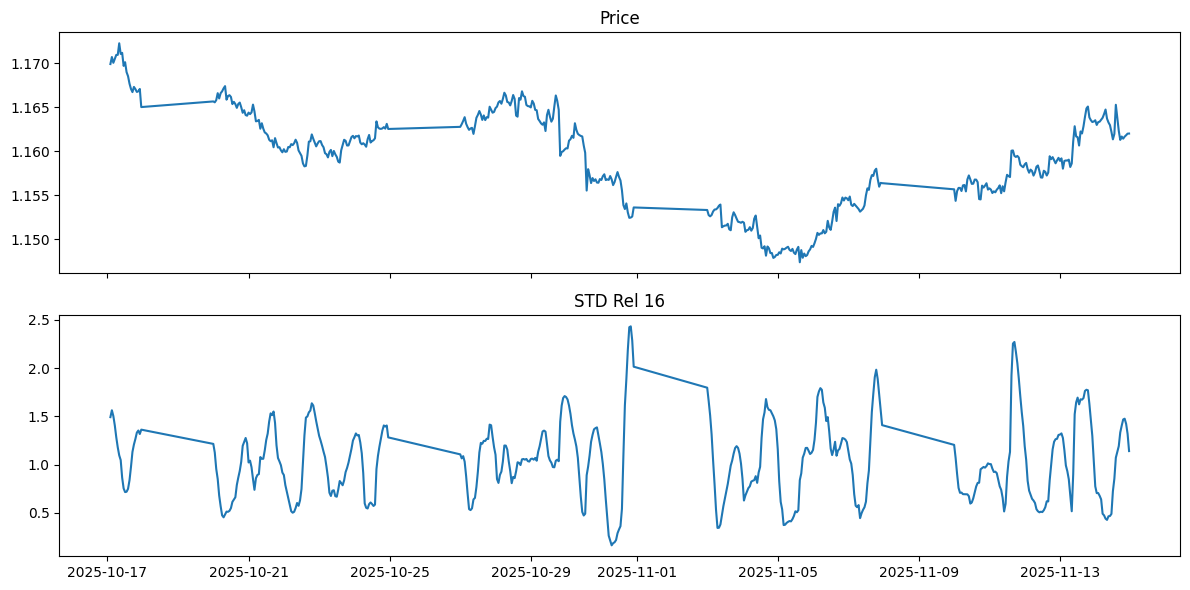

In [9]:
sample = df.iloc[-500:]
fig, ax = plt.subplots(2,1,figsize=(12,6),sharex=True)

ax[0].plot(sample.index, sample["close"])
ax[0].set_title("Price")

ax[1].plot(sample.index, sample["std_rel_16"])
ax[1].set_title("STD Rel 16")

plt.tight_layout()
plt.savefig("C:/Users/LENOVO/AlgoTrading_Research/statistical-range-detection/figures/std_validation.png", dpi=300)
plt.show()

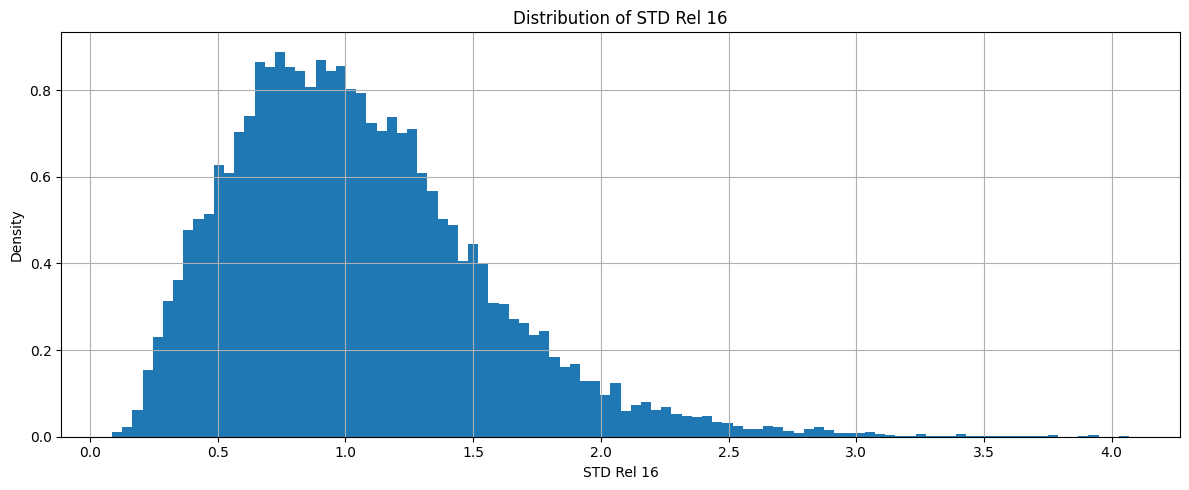

In [10]:
plt.figure(figsize=(12,5))
df["std_rel_16"].dropna().hist(bins=100, density=True)

plt.title("Distribution of STD Rel 16")
plt.xlabel("STD Rel 16")
plt.ylabel("Density")

plt.tight_layout()
plt.savefig("C:/Users/LENOVO/AlgoTrading_Research/statistical-range-detection/figures/std_distribution.png", dpi=300)
plt.show()

In [11]:
df.to_csv(r"C:\Users\LENOVO\AlgoTrading_Research\statistical-range-detection\data\processed\eurusd_h1_features_v2.csv")